<a href="https://colab.research.google.com/github/daningMontano/ACUS_BIODIV_ZCH/blob/main/NOTEBOOK/1_LULC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Land use land cover - ZCH**

By: Daning Montaño

Date: 11/5/2026

# **1. Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import geemap
import ee
import math # Import the math module
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import scipy.stats

# **2. Initialize**

In [2]:
# Trigger the authentication flow.
#  Autenticar la cuenta de Google Earth Engine
ee.Authenticate()
ee.Initialize(project='monitoreofpachamama')

# **3. Data**

## 3.1. AOI

In [3]:
aoi =  ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh")
aoi_buffer_5km = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/Provincia_ZCh_5km_buffer")
acus = ee.FeatureCollection("projects/monitoreofpachamama/assets/ZamoraCH/ACUS_ZCH")

## 3.2. Map biomas

In [4]:
image_asset_id = "projects/mapbiomas-public/assets/ecuador/lulc/collection3/mapbiomas_ecuador_collection3_coverage_v3"
mapbiomas = ee.Image(image_asset_id)
band_names = mapbiomas.bandNames().getInfo()
print("Band names:", band_names)

Band names: ['classification_1985', 'classification_1986', 'classification_1987', 'classification_1988', 'classification_1989', 'classification_1990', 'classification_1991', 'classification_1992', 'classification_1993', 'classification_1994', 'classification_1995', 'classification_1996', 'classification_1997', 'classification_1998', 'classification_1999', 'classification_2000', 'classification_2001', 'classification_2002', 'classification_2003', 'classification_2004', 'classification_2005', 'classification_2006', 'classification_2007', 'classification_2008', 'classification_2009', 'classification_2010', 'classification_2011', 'classification_2012', 'classification_2013', 'classification_2014', 'classification_2015', 'classification_2016', 'classification_2017', 'classification_2018', 'classification_2019', 'classification_2020', 'classification_2021', 'classification_2022', 'classification_2023', 'classification_2024']


# **4. Analysis**

## 4.1. LULC 2024

In [45]:
# Seleccionar datos 2024
mapbiomas_24_acus = mapbiomas.select('classification_2024').clip(acus)

# Diccionario oficial MapBiomas Ecuador Colección 3.0
class_id_colors = {
    1:  '#1f8d49',  # Formación Forestal
    3:  '#1f8d49',  # Bosque
    4:  '#7dc975',  # Bosque abierto
    5:  '#04381d',  # Manglar
    6:  '#026975',  # Bosque inundable

    10: '#d6bc74',  # Formación natural no forestal
    11: '#519799',  # Formación natural no forestal inundable
    12: '#d6bc74',  # Herbazal
    81: '#dfeb62',  # Herbazales y arbustales andinos
    82: '#6fc179',  # Herbazales andinos inundables
    29: '#ffaa5f',  # Afloramiento rocoso
    13: '#d89f5c',  # Otra formación natural no forestal

    14: '#ffefc3',  # Agropecuaria y silvicultura
    9:  '#7a5900',  # Silvicultura
    21: '#ffefc3',  # Mosaico de agricultura y/o pastos
    74: '#be83f7',  # Banano

    22: '#d4271e',  # Área sin vegetación
    24: '#d4271e',  # Infraestructura urbana
    30: '#9c0027',  # Minería
    23: '#ffa07a',  # Playa, duna o banco de arena
    25: '#db4d4f',  # Otra área antrópica sin vegetación
    68: '#e97a7a',  # Otra área natural sin vegetación

    26: '#2532e4',  # Cuerpo de agua
    33: '#2532e4',  # Río, lago u océano
    34: '#93dfe6',  # Glaciar
    31: '#091077',  # Acuicultura

    27: '#ffffff'   # No observado
}

# Paleta completa hasta el ID máximo
max_class_id = max(class_id_colors.keys())

full_palette = ['#000000'] * (max_class_id + 1)

for cid, color in class_id_colors.items():
    full_palette[cid] = color

# Visualización
vis_params = {
    'min': 0,
    'max': max_class_id,
    'palette': full_palette
}

# Leyenda oficial
legend_dict = {
    '1. Formación Forestal': '#1f8d49',
    '3. Bosque': '#1f8d49',
    '4. Bosque abierto': '#7dc975',
    '5. Manglar': '#04381d',
    '6. Bosque inundable': '#026975',
    '10. Formación natural no forestal': '#d6bc74',
    '11. Formación natural no forestal inundable': '#519799',
    '12. Herbazal': '#d6bc74',
    '81. Herbazales y arbustales andinos': '#dfeb62',
    '82. Herbazales andinos inundables': '#6fc179',
    '29. Afloramiento rocoso': '#ffaa5f',
    '13. Otra formación natural no forestal': '#d89f5c',
    '14. Agropecuaria y silvicultura': '#ffefc3',
    '9. Silvicultura': '#7a5900',
    '21. Mosaico de agricultura y/o pastos': '#ffefc3',
    '74. Banano': '#be83f7',
    '22. Área sin vegetación': '#d4271e',
    '24. Infraestructura urbana': '#d4271e',
    '30. Minería': '#9c0027',
    '23. Playa, duna o banco de arena': '#ffa07a',
    '25. Otra área antrópica sin vegetación': '#db4d4f',
    '68. Otra área natural sin vegetación': '#e97a7a',
    '26. Cuerpo de agua': '#2532e4',
    '33. Río, lago u océano': '#2532e4',
    '34. Glaciar': '#93dfe6',
    '31. Acuicultura': '#091077',
    '27. No observado': '#ffffff'
}

Map = geemap.Map()
Map.centerObject(acus, 10)

Map.addLayer(
    mapbiomas_24_acus,
    vis_params,
    'LULC MapBiomas Ecuador 2024'
)

Map.add_legend(
    title='MapBiomas Ecuador Colección 3.0',
    legend_dict=legend_dict
)

#Map

#### Current ext total

In [14]:
# 1. Calcular el área de cada píxel en m2
area_pixel = ee.Image.pixelArea()

# 2. Añadir la banda de clasificación 2024 como grupo
area_img = area_pixel.addBands(mapbiomas_24_acus)

# 3. Reducción por región (ACUS) agrupando por el ID de clase
stats = area_img.reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='id'),
    geometry=acus.geometry(),
    scale=30,
    maxPixels=1e13
)

# 4. Convertir resultados de GEE a DataFrame de Pandas
groups = stats.getInfo().get('groups')

if groups:
    df = pd.DataFrame(groups)

    # Conversión a Hectáreas (1 ha = 10,000 m2)
    df['Area_Ha'] = df['sum'] / 10000

    # Calcular Porcentaje
    total_area = df['Area_Ha'].sum()
    df['Porcentaje_%'] = (df['Area_Ha'] / total_area) * 100

    # Mapear nombres de clases desde legend_dict
    # legend_dict tiene formato 'ID. Nombre': 'Color'
    id_to_name = {int(k.split('.')[0]): k for k in legend_dict.keys()}
    df['Clase'] = df['id'].map(id_to_name)

    # Seleccionar, ordenar y limpiar columnas
    df_final = df[['id', 'Clase', 'Area_Ha', 'Porcentaje_%']].sort_values('Area_Ha', ascending=False)

    # Formatear números para mejor lectura
    df_final['Area_Ha'] = df_final['Area_Ha'].round(2)
    df_final['Porcentaje_%'] = df_final['Porcentaje_%'].round(2)

    print("Extensión de Cobertura y Uso de Suelo 2024 - ACUS")
    display(df_final)
else:
    print("No se encontraron datos para procesar.")

Extensión de Cobertura y Uso de Suelo 2024 - ACUS


,id,Clase,Area_Ha,Porcentaje_%
0,3,3. Bosque,370429.83,83.53
5,21,21. Mosaico de agricultura y/o pastos,35515.71,8.01
14,81,81. Herbazales y arbustales andinos,19781.37,4.46
4,13,13. Otra formación natural no forestal,12045.04,2.72
8,25,25. Otra área antrópica sin vegetación,1971.75,0.44
11,30,30. Minería,1596.99,0.36
12,33,"33. Río, lago u océano",952.31,0.21
10,29,29. Afloramiento rocoso,936.40,0.21
13,68,68. Otra área natural sin vegetación,124.86,0.03
6,23,"23. Playa, duna o banco de arena",43.40,0.01


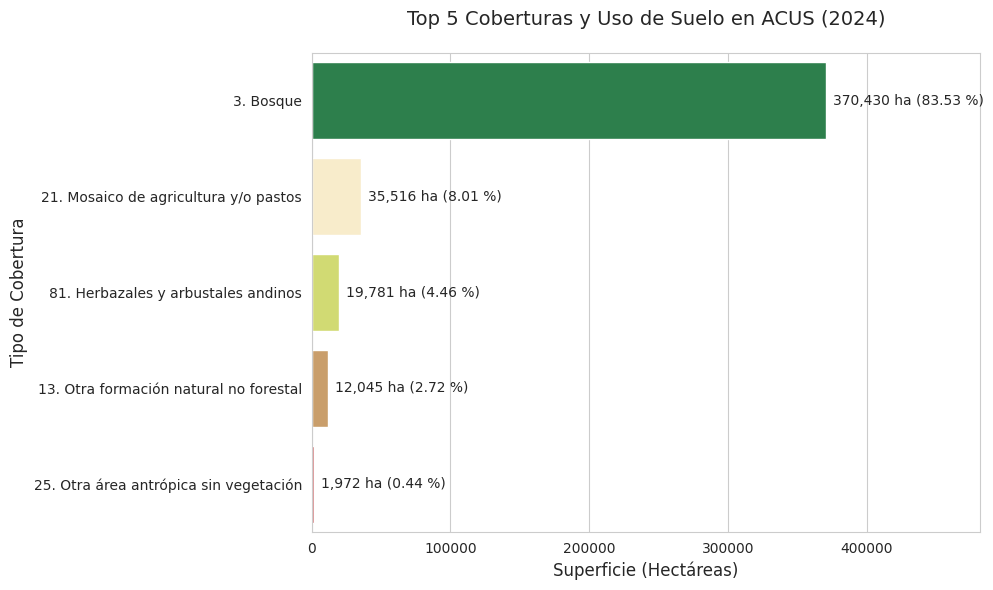

In [16]:
# 1. Obtener las 5 principales coberturas
top_5_df = df_final.head(5).copy()

# 2. Preparar los colores basados en el ID de clase
# Usamos 'id' en minúsculas para coincidir con el DataFrame
colors_top_5 = [class_id_colors.get(row['id'], '#000000') for index, row in top_5_df.iterrows()]

# 3. Crear la gráfica
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(
    x='Area_Ha',
    y='Clase',
    data=top_5_df,
    palette=colors_top_5,
    hue='Clase',
    legend=False
)

# Añadir etiquetas de datos
for i, p in enumerate(ax.patches):
    area_val = top_5_df.iloc[i]['Area_Ha']
    perc_val = top_5_df.iloc[i]['Porcentaje_%']
    ax.annotate(f"{area_val:,.0f} ha ({perc_val} %)",
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points')

plt.title('Top 5 Coberturas y Uso de Suelo en ACUS (2024)', fontsize=14, pad=20)
plt.xlabel('Superficie (Hectáreas)', fontsize=12)
plt.ylabel('Tipo de Cobertura', fontsize=12)
plt.xlim(0, top_5_df['Area_Ha'].max() * 1.3) # Espacio extra para etiquetas

plt.tight_layout()
plt.show()

### Cover by acus

In [18]:
# 1. Obtener la lista de nombres únicos en el ACUS
acus_list = acus.aggregate_array('Nombre').distinct().getInfo()

all_results = []

# 2. Calcular estadísticas para cada unidad
for name in acus_list:
    # Filtrar el ACUS por nombre
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    # Reducción de área
    stats = area_pixel.addBands(mapbiomas_24_acus).reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='id'),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    groups = stats.getInfo().get('groups')

    if groups:
        temp_df = pd.DataFrame(groups)
        temp_df['Nombre_ACUS'] = name
        # Convertir a Ha
        temp_df['Area_Ha'] = temp_df['sum'] / 10000
        # Porcentaje relativo a esta unidad específica
        unit_total = temp_df['Area_Ha'].sum()
        temp_df['Porcentaje_%'] = (temp_df['Area_Ha'] / unit_total) * 100

        all_results.append(temp_df)

# 3. Consolidar resultados
if all_results:
    df_acus_names = pd.concat(all_results)

    # Mapear nombres de clases
    id_to_name = {int(k.split('.')[0]): k for k in legend_dict.keys()}
    df_acus_names['Clase_Cobertura'] = df_acus_names['id'].map(id_to_name)

    # Ordenar y limpiar
    df_acus_names = df_acus_names[['Nombre_ACUS', 'id', 'Clase_Cobertura', 'Area_Ha', 'Porcentaje_%']]
    df_acus_names = df_acus_names.sort_values(['Nombre_ACUS', 'Area_Ha'], ascending=[True, False])

    # Formatear
    df_acus_names['Area_Ha'] = df_acus_names['Area_Ha'].round(2)
    df_acus_names['Porcentaje_%'] = df_acus_names['Porcentaje_%'].round(2)

    display(df_acus_names)
else:
    print('No se pudieron procesar las áreas por nombre.')

,Nombre_ACUS,id,Clase_Cobertura,Area_Ha,Porcentaje_%
0,Bracamoros,3,3. Bosque,99927.52,79.87
3,Bracamoros,21,21. Mosaico de agricultura y/o pastos,19759.35,15.79
2,Bracamoros,13,13. Otra formación natural no forestal,2601.16,2.08
6,Bracamoros,25,25. Otra área antrópica sin vegetación,1507.75,1.21
8,Bracamoros,29,29. Afloramiento rocoso,435.96,0.35
10,Bracamoros,33,"33. Río, lago u océano",416.54,0.33
11,Bracamoros,81,81. Herbazales y arbustales andinos,306.31,0.24
9,Bracamoros,30,30. Minería,142.54,0.11
4,Bracamoros,23,"23. Playa, duna o banco de arena",6.00,0.00
5,Bracamoros,24,24. Infraestructura urbana,3.83,0.00


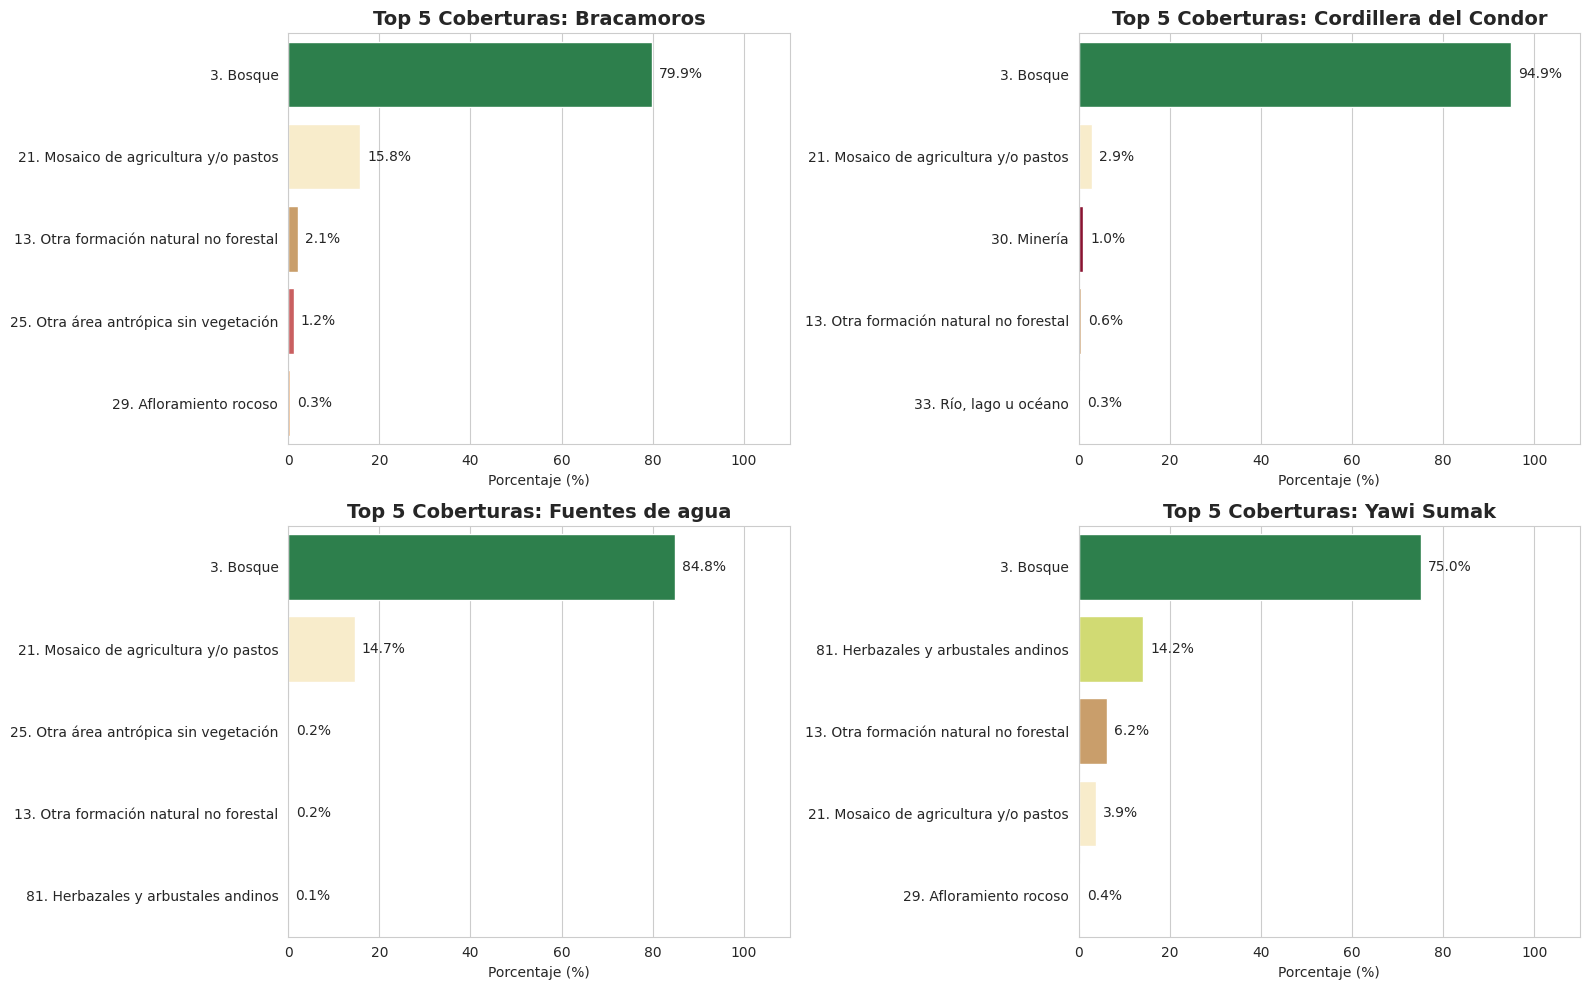

In [19]:

# 1. Obtener los nombres de los ACUS
acus_names = df_acus_names['Nombre_ACUS'].unique()
num_acus = len(acus_names)

# 2. Configurar la figura (subtramas)
cols = 2
rows = math.ceil(num_acus / cols)
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

sns.set_style("whitegrid")

for i, name in enumerate(acus_names):
    # Filtrar top 5 para este ACUS específico
    subset = df_acus_names[df_acus_names['Nombre_ACUS'] == name].head(5).copy()

    # Obtener colores oficiales
    colors = [class_id_colors.get(int(row['id']), '#000000') for _, row in subset.iterrows()]

    # Crear gráfica de barras
    ax = sns.barplot(
        x='Porcentaje_%',
        y='Clase_Cobertura',
        data=subset,
        palette=colors,
        hue='Clase_Cobertura',
        legend=False,
        ax=axes[i]
    )

    # Añadir etiquetas
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(f'{width:.1f}%',
                    (width, p.get_y() + p.get_height() / 2),
                    ha='left', va='center',
                    xytext=(5, 0),
                    textcoords='offset points')

    axes[i].set_title(f'Top 5 Coberturas: {name}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Porcentaje (%)')
    axes[i].set_ylabel('')
    axes[i].set_xlim(0, 110) # Espacio para etiquetas

# Eliminar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 4.2. Time series

### Forest

#### Total

In [20]:

# 1. Definir clases de bosque y años
forest_classes = [1, 3, 4, 5, 6]
years = [int(band.split('_')[1]) for band in band_names]

# 2. Función para calcular área de bosque por año
def get_forest_area(year):
    img = mapbiomas.select(f'classification_{year}').clip(acus)

    # Crear máscara para clases de bosque
    forest_mask = img.remap(forest_classes, [1]*len(forest_classes), 0)

    # Calcular área
    stats = ee.Image.pixelArea().updateMask(forest_mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=acus.geometry(),
        scale=30,
        maxPixels=1e13
    )

    area_m2 = stats.getInfo().get('area')
    return area_m2 / 10000 if area_m2 else 0

# 3. Procesar cronología (esto puede tardar un momento)
print("Calculando serie temporal (1985-2024)... Por favor espera.")
time_series_data = []

for year in years:
    area_ha = get_forest_area(year)
    time_series_data.append({'Year': year, 'Forest_Area_Ha': area_ha})

df_ts = pd.DataFrame(time_series_data)

# Calcular porcentaje respecto al área total del ACUS (usando el total de 2024 como referencia)
total_acus_area = df_final['Area_Ha'].sum()
df_ts['Forest_Percentage'] = (df_ts['Forest_Area_Ha'] / total_acus_area) * 100

display(df_ts.head())
print("Datos procesados correctamente.")

Calculando serie temporal (1985-2024)... Por favor espera.


,Year,Forest_Area_Ha,Forest_Percentage
0,1985,392791.992365,88.575014
1,1986,392790.675496,88.574717
2,1987,391852.277520,88.363107
3,1988,391031.067348,88.177923
4,1989,390667.996271,88.096050


Datos procesados correctamente.


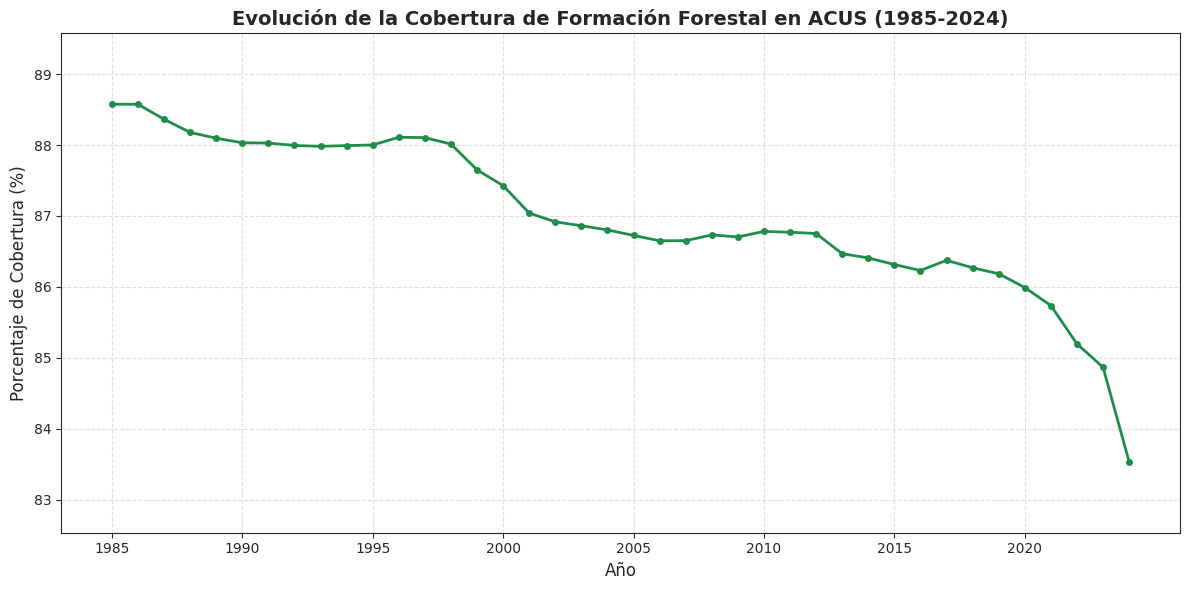

In [21]:

# 4. Crear la gráfica de serie de tiempo
plt.figure(figsize=(12, 6))
sns.set_style("ticks")

# Dibujar línea y puntos
plt.plot(df_ts['Year'], df_ts['Forest_Percentage'],
         marker='o', linestyle='-', color='#1f8d49', linewidth=2, markersize=4)

# Configurar estética
plt.title('Evolución de la Cobertura de Formación Forestal en ACUS (1985-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje de Cobertura (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajustar límites y ticks
plt.xticks(range(1985, 2025, 5))
plt.ylim(df_ts['Forest_Percentage'].min() - 1, df_ts['Forest_Percentage'].max() + 1)

plt.tight_layout()
plt.show()

#### Por ACUS

In [25]:
# 1. Calcular serie temporal de bosque para cada unidad ACUS (Filtrado 2015+)
print("Calculando series temporales por unidad (2015 en adelante)...")

unit_ts_results = []

# Filtrar lista de años para 2015 en adelante
years_filtered = [y for y in years if y >= 2015]

if not years_filtered:
    print("Nota: No hay datos disponibles para el año 2015 o posteriores en la Colección 3 de MapBiomas (actualmente hasta 2024).")
else:
    for name in acus_list:
        unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()
        unit_total_area_ha = df_acus_names[df_acus_names['Nombre_ACUS'] == name]['Area_Ha'].sum()

        for year in years_filtered:
            img = mapbiomas.select(f'classification_{year}').clip(unit_geom)
            forest_mask = img.remap(forest_classes, [1]*len(forest_classes), 0)

            stats = ee.Image.pixelArea().updateMask(forest_mask).reduceRegion(
                reducer=ee.Reducer.sum(),
                geometry=unit_geom,
                scale=30,
                maxPixels=1e13
            )

            area_m2 = stats.getInfo().get('area')
            area_ha = area_m2 / 10000 if area_m2 else 0
            perc = (area_ha / unit_total_area_ha) * 100 if unit_total_area_ha > 0 else 0

            unit_ts_results.append({
                'Nombre_ACUS': name,
                'Year': year,
                'Forest_Area_Ha': area_ha,
                'Forest_Percentage': perc
            })

df_unit_ts = pd.DataFrame(unit_ts_results)
display(df_unit_ts)

Calculando series temporales por unidad (2015 en adelante)...


,Nombre_ACUS,Year,Forest_Area_Ha,Forest_Percentage
0,Bracamoros,2015,107847.522159,86.203104
1,Bracamoros,2016,107647.156491,86.042950
2,Bracamoros,2017,107990.180092,86.317131
3,Bracamoros,2018,107661.170559,86.054152
4,Bracamoros,2019,107458.636608,85.892265
5,Bracamoros,2020,107166.716875,85.658932
6,Bracamoros,2021,106506.703244,85.131380
7,Bracamoros,2022,104766.521727,83.740444
8,Bracamoros,2023,103666.795922,82.861427
9,Bracamoros,2024,99927.520678,79.872604


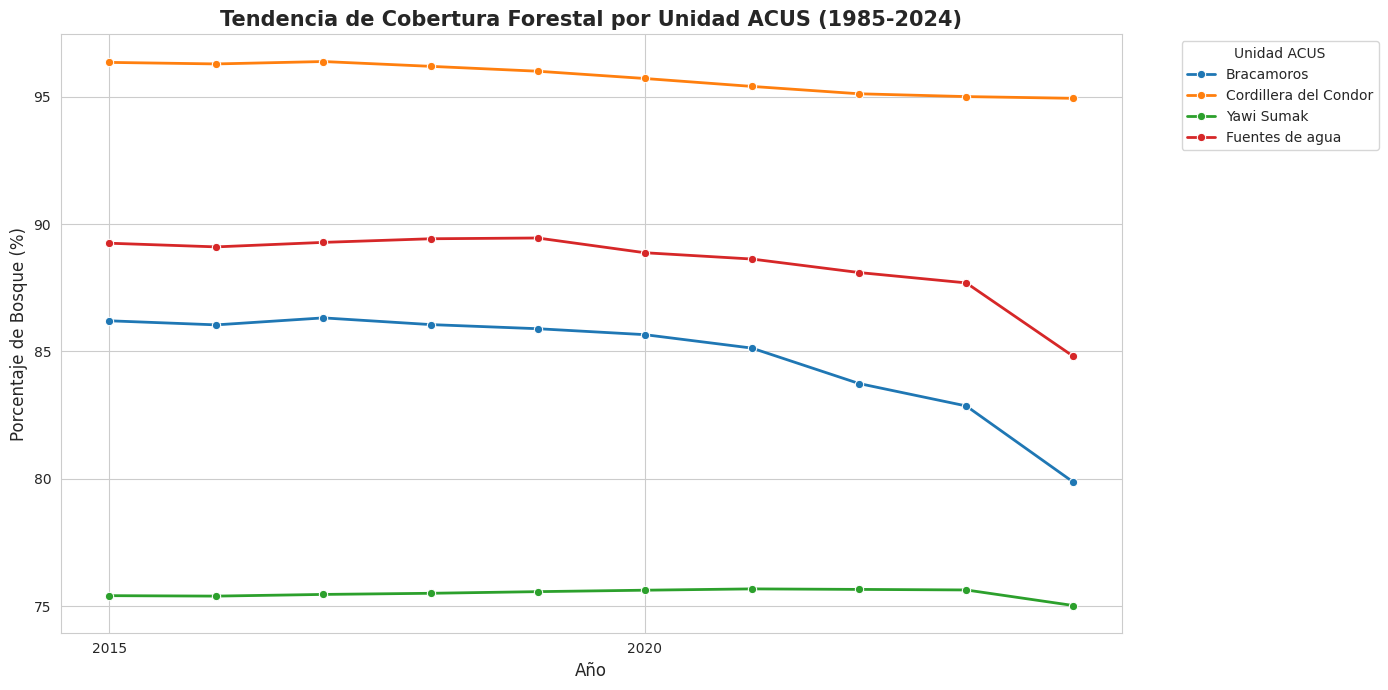

In [26]:
# 2. Gráfica comparativa de series de tiempo por ACUS
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_unit_ts,
    x='Year',
    y='Forest_Percentage',
    hue='Nombre_ACUS',
    marker='o',
    linewidth=2
)

plt.title('Tendencia de Cobertura Forestal por Unidad ACUS (1985-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Porcentaje de Bosque (%)', fontsize=12)
plt.legend(title='Unidad ACUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2015, 2024, 5))

plt.tight_layout()
plt.show()

### Non-forest natural formation

#### Total

Calculando serie temporal para Formaci3n Natural No Forestal (2015+)...


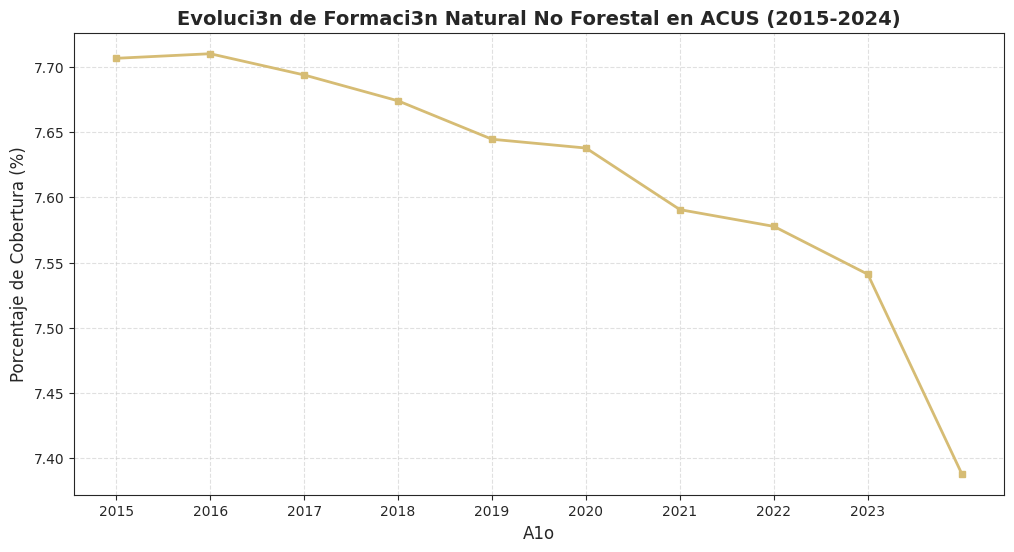

In [28]:
# 1. Definir clases de formaci3n natural no forestal
non_forest_natural = [10, 11, 12, 13, 29, 81, 82]

# 2. Filtrar a1os para 2015 en adelante
years_filtered_nf = [y for y in years if y >= 2015]

# 3. Funci3n para calcular el 1rea por a1o
def get_non_forest_area(year):
    img = mapbiomas.select(f'classification_{year}').clip(acus)
    mask = img.remap(non_forest_natural, [1]*len(non_forest_natural), 0)

    stats = ee.Image.pixelArea().updateMask(mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=acus.geometry(),
        scale=30,
        maxPixels=1e13
    )

    area_m2 = stats.getInfo().get('area')
    return area_m2 / 10000 if area_m2 else 0

# 4. Procesar cronolog3a (2015-2024)
print("Calculando serie temporal para Formaci3n Natural No Forestal (2015+)...")
ts_non_forest = []

for year in years_filtered_nf:
    area_ha = get_non_forest_area(year)
    ts_non_forest.append({'Year': year, 'Area_Ha': area_ha})

df_ts_nf = pd.DataFrame(ts_non_forest)

if not df_ts_nf.empty:
    df_ts_nf['Percentage'] = (df_ts_nf['Area_Ha'] / total_acus_area) * 100

    # 5. Crear la gr1fica de serie de tiempo
    plt.figure(figsize=(12, 6))
    sns.set_style("ticks")
    plt.plot(df_ts_nf['Year'], df_ts_nf['Percentage'],
             marker='s', linestyle='-', color='#d6bc74', linewidth=2, markersize=4)
    plt.title('Evoluci3n de Formaci3n Natural No Forestal en ACUS (2015-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('A1o', fontsize=12)
    plt.ylabel('Porcentaje de Cobertura (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(2015, 2024, 1))
    plt.show()
else:
    print("No hay datos disponibles para el periodo seleccionado.")

#### Por ACUS

Calculando series temporales por unidad (2015-2024)... Por favor espera.


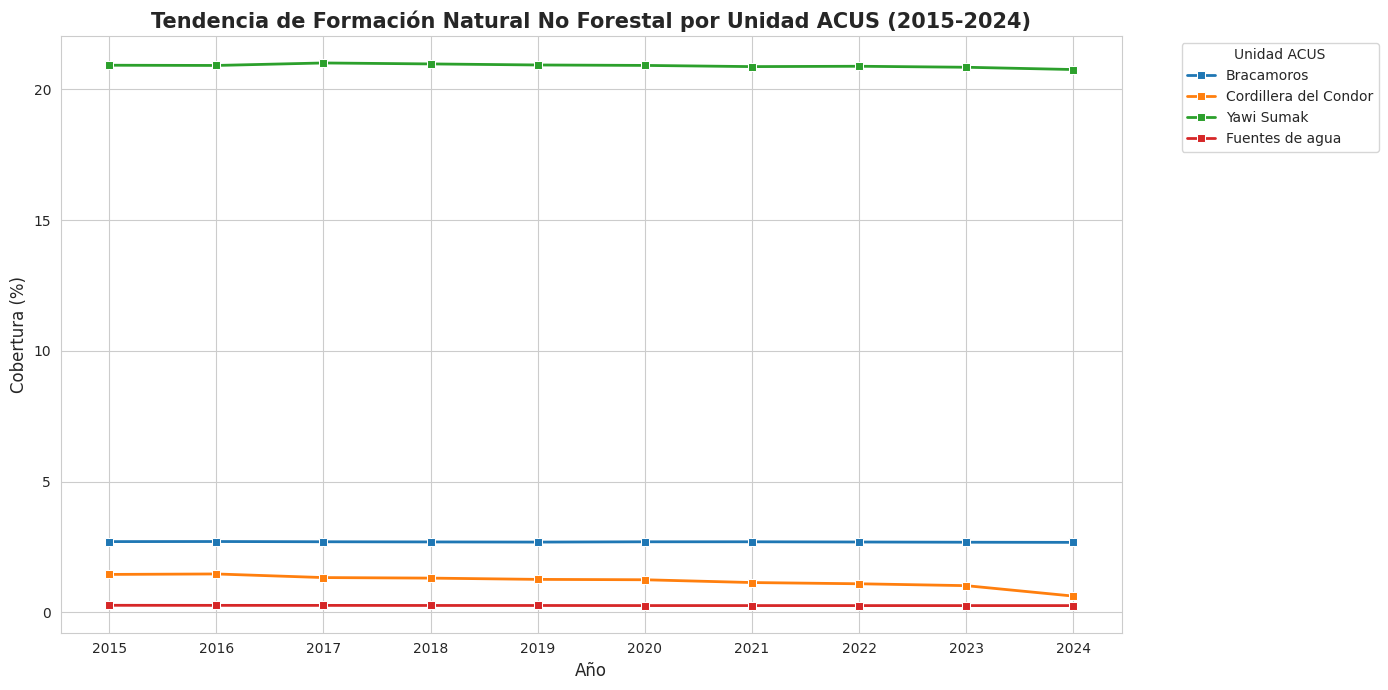

In [29]:
# 1. Calcular serie temporal de Formación Natural No Forestal por unidad ACUS
print("Calculando series temporales por unidad (2015-2024)... Por favor espera.")

unit_nf_results = []
years_filtered_nf = [y for y in years if y >= 2015]
non_forest_natural = [10, 11, 12, 13, 29, 81, 82]

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()
    # Obtener el área total de la unidad para el cálculo de porcentaje
    unit_total_area_ha = df_acus_names[df_acus_names['Nombre_ACUS'] == name]['Area_Ha'].sum()

    for year in years_filtered_nf:
        img = mapbiomas.select(f'classification_{year}').clip(unit_geom)
        nf_mask = img.remap(non_forest_natural, [1]*len(non_forest_natural), 0)

        stats = ee.Image.pixelArea().updateMask(nf_mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=unit_geom,
            scale=30,
            maxPixels=1e13
        )

        area_m2 = stats.getInfo().get('area')
        area_ha = area_m2 / 10000 if area_m2 else 0
        perc = (area_ha / unit_total_area_ha) * 100 if unit_total_area_ha > 0 else 0

        unit_nf_results.append({
            'Nombre_ACUS': name,
            'Year': year,
            'Area_Ha': area_ha,
            'Percentage': perc
        })

df_unit_ts_nf = pd.DataFrame(unit_nf_results)

# 2. Gráfica comparativa
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_unit_ts_nf,
    x='Year',
    y='Percentage',
    hue='Nombre_ACUS',
    marker='s',
    linewidth=2
)

plt.title('Tendencia de Formación Natural No Forestal por Unidad ACUS (2015-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura (%)', fontsize=12)
plt.legend(title='Unidad ACUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2015, 2025, 1))

plt.tight_layout()
plt.show()

### Agriculture

#### Total

Calculando serie temporal para Mosaico de agricultura y/o pastos en todo el ACUS (2015+)...


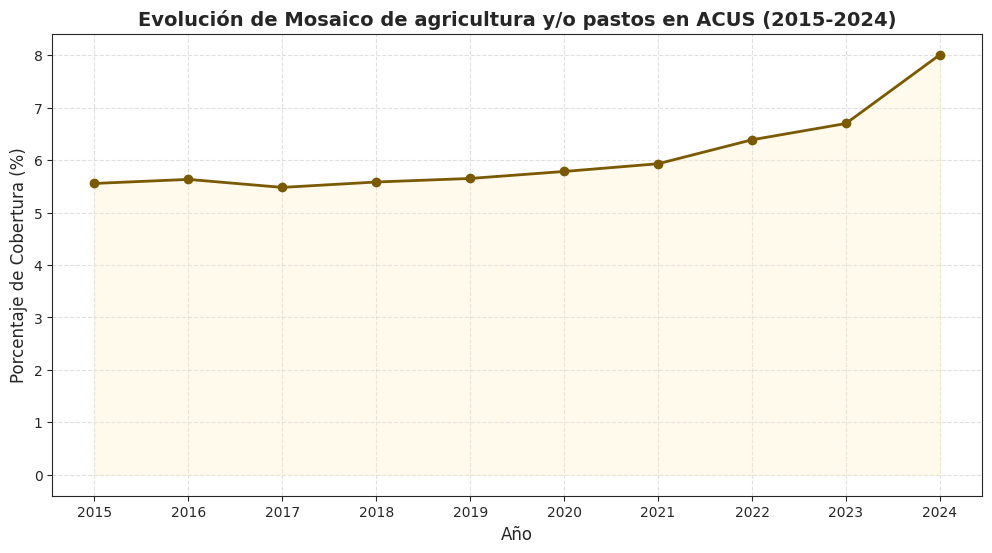

In [33]:
# 1. Definir la clase de Mosaico de agricultura y/o pastos
agro_pasto_id = 21

# 2. Filtrar años para 2015 en adelante
years_filtered_agro = [y for y in years if y >= 2015]

# 3. Función para calcular el área por año para todo el ACUS
def get_agro_area(year):
    img = mapbiomas.select(f'classification_{year}').clip(acus)
    mask = img.eq(agro_pasto_id)

    stats = ee.Image.pixelArea().updateMask(mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=acus.geometry(),
        scale=30,
        maxPixels=1e13
    )

    area_m2 = stats.getInfo().get('area')
    return area_m2 / 10000 if area_m2 else 0

# 4. Procesar cronología (2015-2024)
print("Calculando serie temporal para Mosaico de agricultura y/o pastos en todo el ACUS (2015+)...")
ts_agro_total = []

for year in years_filtered_agro:
    area_ha = get_agro_area(year)
    ts_agro_total.append({'Year': year, 'Area_Ha': area_ha})

df_ts_agro_total = pd.DataFrame(ts_agro_total)

if not df_ts_agro_total.empty:
    # Usar el área total del ACUS previamente calculada
    df_ts_agro_total['Percentage'] = (df_ts_agro_total['Area_Ha'] / total_acus_area) * 100

    # 5. Crear la gráfica de serie de tiempo
    plt.figure(figsize=(12, 6))
    sns.set_style("ticks")

    color_21 = class_id_colors.get(21, '#ffefc3')

    plt.plot(df_ts_agro_total['Year'], df_ts_agro_total['Percentage'],
             marker='o', linestyle='-', color='#7a5900', linewidth=2, markersize=6)

    plt.fill_between(df_ts_agro_total['Year'], df_ts_agro_total['Percentage'], color=color_21, alpha=0.3)

    plt.title('Evolución de Mosaico de agricultura y/o pastos en ACUS (2015-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Porcentaje de Cobertura (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(2015, 2025, 1))
    plt.show()
else:
    print("No hay datos disponibles para el periodo seleccionado.")

#### Por ACUS

Calculando series temporales para Mosaico de agricultura y/o pastos (2015-2024)...


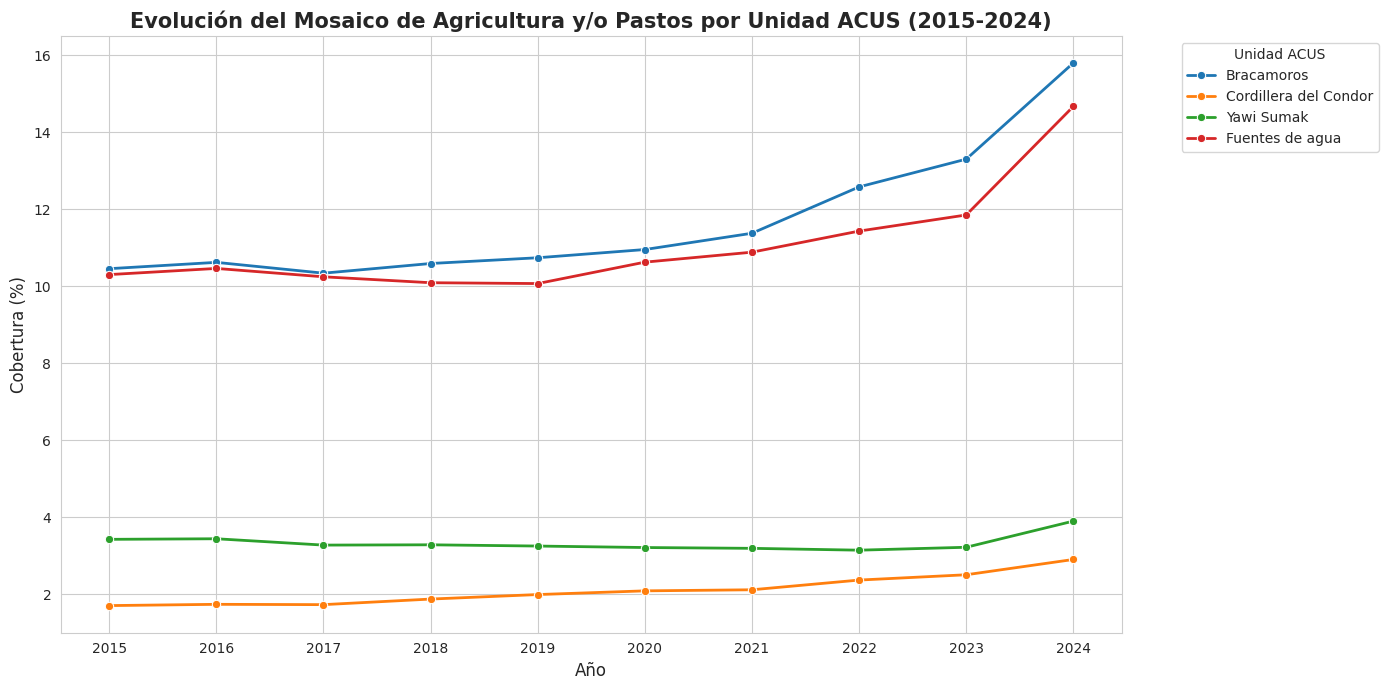

In [31]:
# 1. Calcular serie temporal de 'Mosaico de agricultura y/o pastos' (ID 21) por unidad ACUS
print("Calculando series temporales para Mosaico de agricultura y/o pastos (2015-2024)...")

unit_agro_results = []
years_filtered_agro = [y for y in years if y >= 2015]
agro_pasto_id = 21

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()
    # Obtener el área total de la unidad para el cálculo de porcentaje
    unit_total_area_ha = df_acus_names[df_acus_names['Nombre_ACUS'] == name]['Area_Ha'].sum()

    for year in years_filtered_agro:
        img = mapbiomas.select(f'classification_{year}').clip(unit_geom)
        # Máscara específica para la clase 21
        agro_mask = img.eq(agro_pasto_id)

        stats = ee.Image.pixelArea().updateMask(agro_mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=unit_geom,
            scale=30,
            maxPixels=1e13
        )

        area_m2 = stats.getInfo().get('area')
        area_ha = area_m2 / 10000 if area_m2 else 0
        perc = (area_ha / unit_total_area_ha) * 100 if unit_total_area_ha > 0 else 0

        unit_agro_results.append({
            'Nombre_ACUS': name,
            'Year': year,
            'Area_Ha': area_ha,
            'Percentage': perc
        })

df_unit_ts_agro = pd.DataFrame(unit_agro_results)

# 2. Gráfica comparativa de serie de tiempo
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_unit_ts_agro,
    x='Year',
    y='Percentage',
    hue='Nombre_ACUS',
    marker='o',
    linewidth=2
)

plt.title('Evolución del Mosaico de Agricultura y/o Pastos por Unidad ACUS (2015-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura (%)', fontsize=12)
plt.legend(title='Unidad ACUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2015, 2025, 1))

plt.tight_layout()
plt.show()

### Urban infrastructure

#### Total

Calculando serie temporal para Infraestructura urbana en todo el ACUS (2015+)...


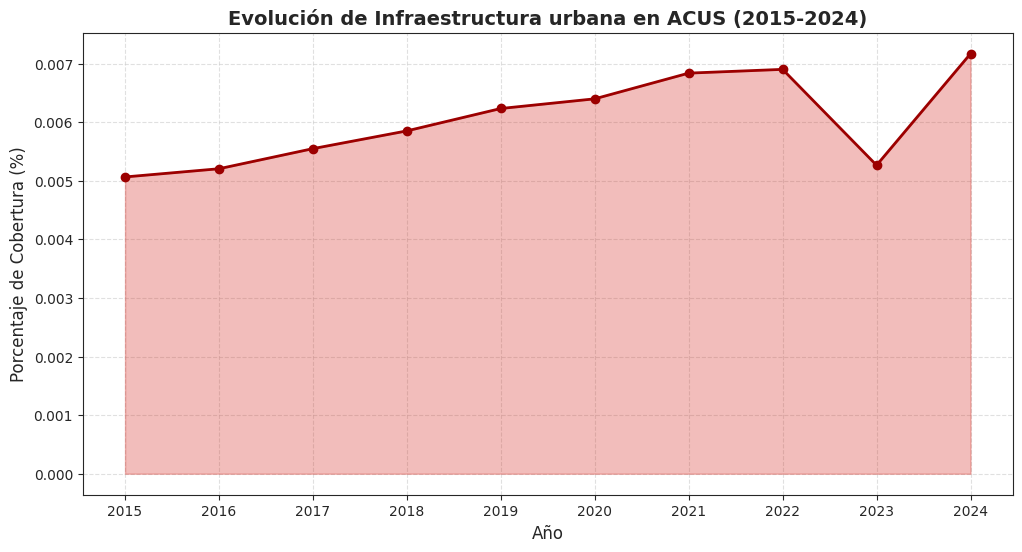

In [34]:
# 1. Definir la clase de Infraestructura urbana
urban_id = 24

# 2. Filtrar años para 2015 en adelante
years_filtered_urban = [y for y in years if y >= 2015]

# 3. Función para calcular el área por año para todo el ACUS
def get_urban_area(year):
    img = mapbiomas.select(f'classification_{year}').clip(acus)
    mask = img.eq(urban_id)

    stats = ee.Image.pixelArea().updateMask(mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=acus.geometry(),
        scale=30,
        maxPixels=1e13
    )

    area_m2 = stats.getInfo().get('area')
    return area_m2 / 10000 if area_m2 else 0

# 4. Procesar cronología (2015-2024)
print("Calculando serie temporal para Infraestructura urbana en todo el ACUS (2015+)...")
ts_urban_total = []

for year in years_filtered_urban:
    area_ha = get_urban_area(year)
    ts_urban_total.append({'Year': year, 'Area_Ha': area_ha})

df_ts_urban_total = pd.DataFrame(ts_urban_total)

if not df_ts_urban_total.empty:
    # Usar el área total del ACUS previamente calculada
    df_ts_urban_total['Percentage'] = (df_ts_urban_total['Area_Ha'] / total_acus_area) * 100

    # 5. Crear la gráfica de serie de tiempo
    plt.figure(figsize=(12, 6))
    sns.set_style("ticks")

    color_24 = class_id_colors.get(24, '#d4271e')

    plt.plot(df_ts_urban_total['Year'], df_ts_urban_total['Percentage'],
             marker='o', linestyle='-', color='#9c0000', linewidth=2, markersize=6)

    plt.fill_between(df_ts_urban_total['Year'], df_ts_urban_total['Percentage'], color=color_24, alpha=0.3)

    plt.title('Evolución de Infraestructura urbana en ACUS (2015-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Porcentaje de Cobertura (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(2015, 2025, 1))
    plt.show()
else:
    print("No hay datos disponibles para el periodo seleccionado.")

#### Por ACUS

Calculando series temporales para Infraestructura urbana por unidad (2015-2024)...


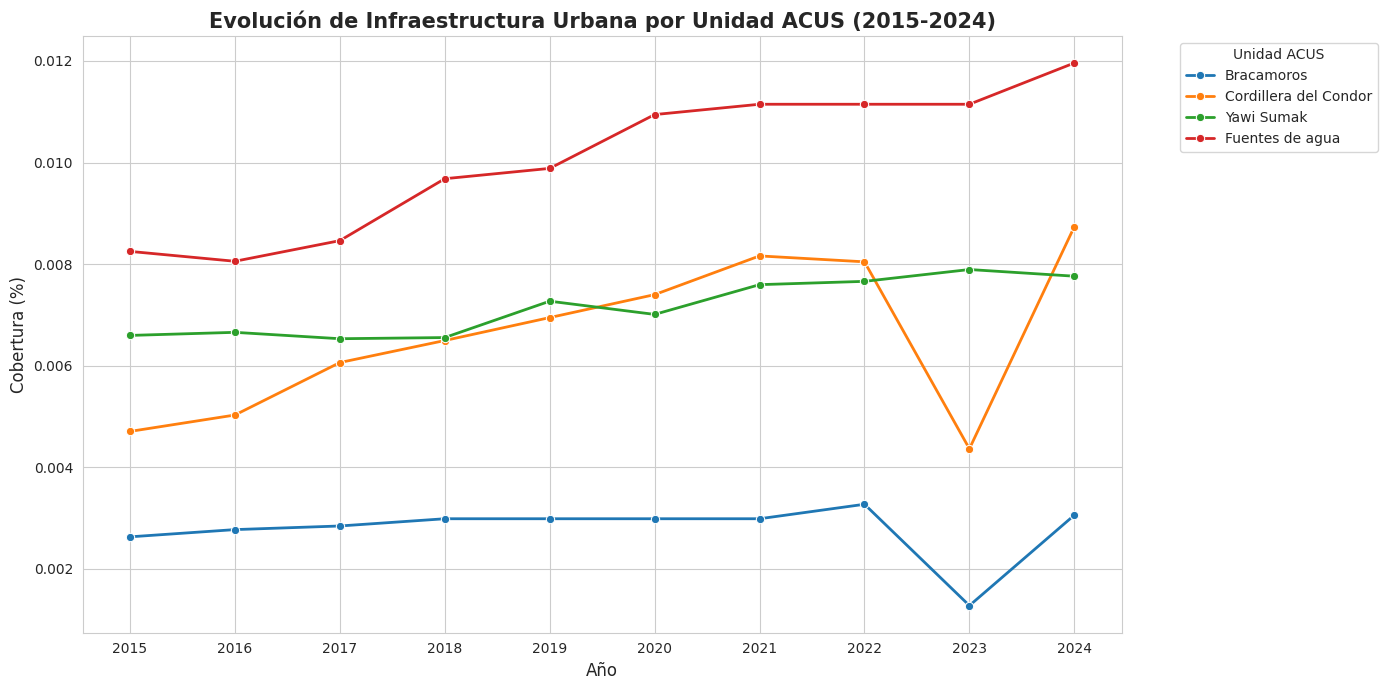

In [35]:
# 1. Calcular serie temporal de 'Infraestructura urbana' (ID 24) por unidad ACUS
print("Calculando series temporales para Infraestructura urbana por unidad (2015-2024)...")

unit_urban_results = []
years_filtered_urban = [y for y in years if y >= 2015]
urban_id = 24

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()
    # Obtener el área total de la unidad para el cálculo de porcentaje
    unit_total_area_ha = df_acus_names[df_acus_names['Nombre_ACUS'] == name]['Area_Ha'].sum()

    for year in years_filtered_urban:
        img = mapbiomas.select(f'classification_{year}').clip(unit_geom)
        # Máscara específica para la clase 24
        urban_mask = img.eq(urban_id)

        stats = ee.Image.pixelArea().updateMask(urban_mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=unit_geom,
            scale=30,
            maxPixels=1e13
        )

        area_m2 = stats.getInfo().get('area')
        area_ha = area_m2 / 10000 if area_m2 else 0
        perc = (area_ha / unit_total_area_ha) * 100 if unit_total_area_ha > 0 else 0

        unit_urban_results.append({
            'Nombre_ACUS': name,
            'Year': year,
            'Area_Ha': area_ha,
            'Percentage': perc
        })

df_unit_ts_urban = pd.DataFrame(unit_urban_results)

# 2. Gráfica comparativa de serie de tiempo por ACUS
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.lineplot(
    data=df_unit_ts_urban,
    x='Year',
    y='Percentage',
    hue='Nombre_ACUS',
    marker='o',
    linewidth=2
)

plt.title('Evolución de Infraestructura Urbana por Unidad ACUS (2015-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura (%)', fontsize=12)
plt.legend(title='Unidad ACUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2015, 2025, 1))

plt.tight_layout()
plt.show()

### Mining

#### Total

Calculando serie temporal para Minería en todo el ACUS (2015+)...


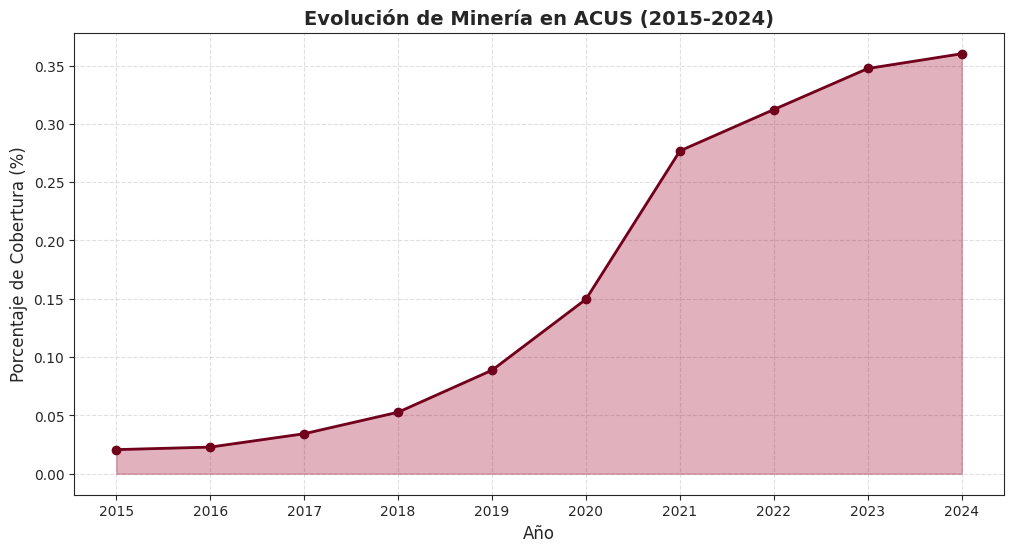

In [37]:
# 1. Definir la clase de Minería
mining_id = 30

# 2. Filtrar años para 2015 en adelante
years_filtered_mining = [y for y in years if y >= 2015]

# 3. Función para calcular el área por año para todo el ACUS
def get_mining_area(year):
    img = mapbiomas.select(f'classification_{year}').clip(acus)
    mask = img.eq(mining_id)

    stats = ee.Image.pixelArea().updateMask(mask).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=acus.geometry(),
        scale=30,
        maxPixels=1e13
    )

    area_m2 = stats.getInfo().get('area')
    return area_m2 / 10000 if area_m2 else 0

# 4. Procesar cronología (2015-2024)
print("Calculando serie temporal para Minería en todo el ACUS (2015+)...")
ts_mining_total = []

for year in years_filtered_mining:
    area_ha = get_mining_area(year)
    ts_mining_total.append({'Year': year, 'Area_Ha': area_ha})

df_ts_mining_total = pd.DataFrame(ts_mining_total)

if not df_ts_mining_total.empty:
    # Usar el área total del ACUS previamente calculada
    df_ts_mining_total['Percentage'] = (df_ts_mining_total['Area_Ha'] / total_acus_area) * 100

    # 5. Crear la gráfica de serie de tiempo
    plt.figure(figsize=(12, 6))
    sns.set_style("ticks")

    color_30 = class_id_colors.get(30, '#9c0027')

    plt.plot(df_ts_mining_total['Year'], df_ts_mining_total['Percentage'],
             marker='o', linestyle='-', color='#70001c', linewidth=2, markersize=6)

    plt.fill_between(df_ts_mining_total['Year'], df_ts_mining_total['Percentage'], color=color_30, alpha=0.3)

    plt.title('Evolución de Minería en ACUS (2015-2024)', fontsize=14, fontweight='bold')
    plt.xlabel('Año', fontsize=12)
    plt.ylabel('Porcentaje de Cobertura (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(2015, 2025, 1))
    plt.show()
else:
    print("No hay datos disponibles para el periodo seleccionado.")

#### Por ACUS

Calculando series temporales para Minería por unidad (2015-2024)...


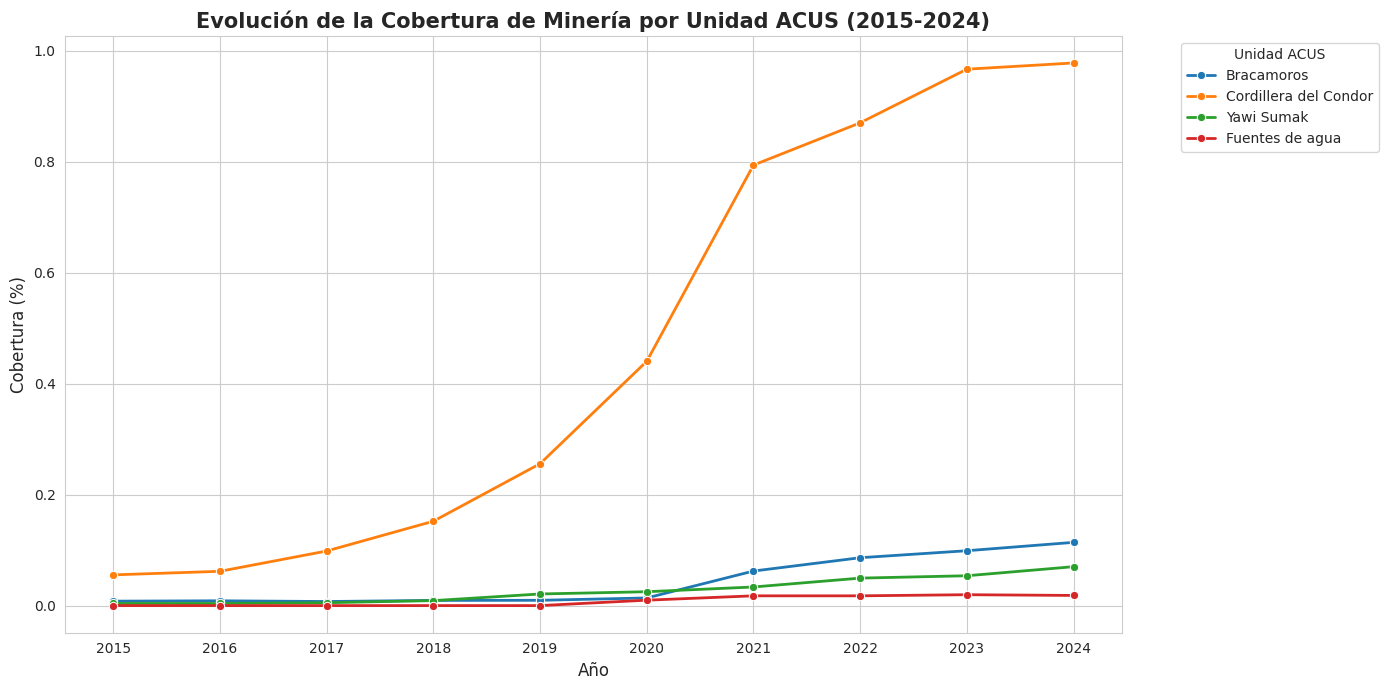

In [36]:
# 1. Calcular serie temporal de 'Minería' (ID 30) por unidad ACUS
print("Calculando series temporales para Minería por unidad (2015-2024)...")

unit_mining_results = []
years_filtered_mining = [y for y in years if y >= 2015]
mining_id = 30

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()
    # Obtener el área total de la unidad para el cálculo de porcentaje
    unit_total_area_ha = df_acus_names[df_acus_names['Nombre_ACUS'] == name]['Area_Ha'].sum()

    for year in years_filtered_mining:
        img = mapbiomas.select(f'classification_{year}').clip(unit_geom)
        # Máscara específica para la clase 30
        mining_mask = img.eq(mining_id)

        stats = ee.Image.pixelArea().updateMask(mining_mask).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=unit_geom,
            scale=30,
            maxPixels=1e13
        )

        area_m2 = stats.getInfo().get('area')
        area_ha = area_m2 / 10000 if area_m2 else 0
        perc = (area_ha / unit_total_area_ha) * 100 if unit_total_area_ha > 0 else 0

        unit_mining_results.append({
            'Nombre_ACUS': name,
            'Year': year,
            'Area_Ha': area_ha,
            'Percentage': perc
        })

df_unit_ts_mining = pd.DataFrame(unit_mining_results)

# 2. Gráfica comparativa de serie de tiempo por ACUS
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

# Color oficial para minería según el diccionario previo
mining_color = '#9c0027'

sns.lineplot(
    data=df_unit_ts_mining,
    x='Year',
    y='Percentage',
    hue='Nombre_ACUS',
    marker='o',
    linewidth=2
)

plt.title('Evolución de la Cobertura de Minería por Unidad ACUS (2015-2024)', fontsize=15, fontweight='bold')
plt.xlabel('Año', fontsize=12)
plt.ylabel('Cobertura (%)', fontsize=12)
plt.legend(title='Unidad ACUS', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(range(2015, 2025, 1))

plt.tight_layout()
plt.show()

## 4.3. Procentaje de área del total ZCH

### Bosque

In [39]:
# 1. Definir clases de bosque
forest_classes = [1, 3, 4, 5, 6]

# 2. Calcular bosque total en el AOI (Provincia) para 2024
img_2024_aoi = mapbiomas.select('classification_2024').clip(aoi)
forest_mask_aoi = img_2024_aoi.remap(forest_classes, [1]*len(forest_classes), 0)

stats_aoi = ee.Image.pixelArea().updateMask(forest_mask_aoi).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

total_forest_aoi_ha = (stats_aoi.getInfo().get('area') or 0) / 10000
print(f"Total de bosque en el AOI (2024): {total_forest_aoi_ha:,.2f} ha")

# 3. Calcular bosque en cada ACUS y su porcentaje respecto al total del AOI
acus_forest_results = []

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    img_unit = mapbiomas.select('classification_2024').clip(unit_geom)
    forest_mask_unit = img_unit.remap(forest_classes, [1]*len(forest_classes), 0)

    stats_unit = ee.Image.pixelArea().updateMask(forest_mask_unit).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    forest_unit_ha = (stats_unit.getInfo().get('area') or 0) / 10000
    # Porcentaje del bosque del AOI que está en este ACUS
    perc_of_aoi_forest = (forest_unit_ha / total_forest_aoi_ha) * 100 if total_forest_aoi_ha > 0 else 0

    acus_forest_results.append({
        'Nombre_ACUS': name,
        'Bosque_en_ACUS_Ha': forest_unit_ha,
        'Porcentaje_del_Total_AOI_%': perc_of_aoi_forest
    })

df_acus_forest_contrib = pd.DataFrame(acus_forest_results)

print("\nContribución de cada ACUS al total de bosque de la provincia:")
display(df_acus_forest_contrib.sort_values('Bosque_en_ACUS_Ha', ascending=False))

Total de bosque en el AOI (2024): 740,331.76 ha

Contribución de cada ACUS al total de bosque de la provincia:


,Nombre_ACUS,Bosque_en_ACUS_Ha,Porcentaje_del_Total_AOI_%
1,Cordillera del Condor,131102.317214,17.708590
2,Yawi Sumak,102855.918984,13.893220
0,Bracamoros,99927.520678,13.497668
3,Fuentes de agua,37248.975568,5.031390


### Area naturales

In [40]:
# 1. Definir todas las clases naturales (forestales y no forestales)
natural_ids = [1, 3, 4, 5, 6, 10, 11, 12, 13, 29, 81, 82]

# 2. Calcular el total de áreas naturales en el AOI (Provincia) para 2024
img_2024_aoi = mapbiomas.select('classification_2024').clip(aoi)
natural_mask_aoi = img_2024_aoi.remap(natural_ids, [1]*len(natural_ids), 0)

stats_aoi = ee.Image.pixelArea().updateMask(natural_mask_aoi).reduceRegion(
    reducer=ee.Reducer.sum(),
    geometry=aoi.geometry(),
    scale=30,
    maxPixels=1e13
)

total_natural_aoi_ha = (stats_aoi.getInfo().get('area') or 0) / 10000
print(f"Total de Áreas Naturales en el AOI (2024): {total_natural_aoi_ha:,.2f} ha")

# 3. Calcular áreas naturales en cada ACUS y su porcentaje respecto al total provincial
acus_natural_results = []

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    img_unit = mapbiomas.select('classification_2024').clip(unit_geom)
    natural_mask_unit = img_unit.remap(natural_ids, [1]*len(natural_ids), 0)

    stats_unit = ee.Image.pixelArea().updateMask(natural_mask_unit).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    natural_unit_ha = (stats_unit.getInfo().get('area') or 0) / 10000
    # Porcentaje del total provincial natural que está en este ACUS
    perc_of_aoi_natural = (natural_unit_ha / total_natural_aoi_ha) * 100 if total_natural_aoi_ha > 0 else 0

    acus_natural_results.append({
        'Nombre_ACUS': name,
        'Area_Natural_en_ACUS_Ha': natural_unit_ha,
        'Porcentaje_del_Total_Natural_Provincial_%': perc_of_aoi_natural
    })

df_acus_natural_contrib = pd.DataFrame(acus_natural_results)

print("\nContribución de cada ACUS al total de áreas naturales de la provincia:")
display(df_acus_natural_contrib.sort_values('Area_Natural_en_ACUS_Ha', ascending=False))

Total de Áreas Naturales en el AOI (2024): 813,263.33 ha

Contribución de cada ACUS al total de áreas naturales de la provincia:


,Nombre_ACUS,Area_Natural_en_ACUS_Ha,Porcentaje_del_Total_Natural_Provincial_%
1,Cordillera del Condor,131954.411253,16.225300
2,Yawi Sumak,131315.089967,16.146688
0,Bracamoros,103271.045385,12.698353
3,Fuentes de agua,37360.503550,4.593900


## 4.4. Pérdida áreas naturales

Calculando pérdida de áreas naturales entre 2015 y 2024 por unidad ACUS...


,Nombre_ACUS,Natural_Area_2015_Ha,Natural_Area_2024_Ha,Pérdida_Ha
0,Bracamoros,111227.766274,103271.045385,7956.720889
1,Cordillera del Condor,135046.783680,131954.411253,3092.372427
3,Fuentes de agua,39315.065156,37360.503550,1954.561607
2,Yawi Sumak,132071.456730,131315.089967,756.366763


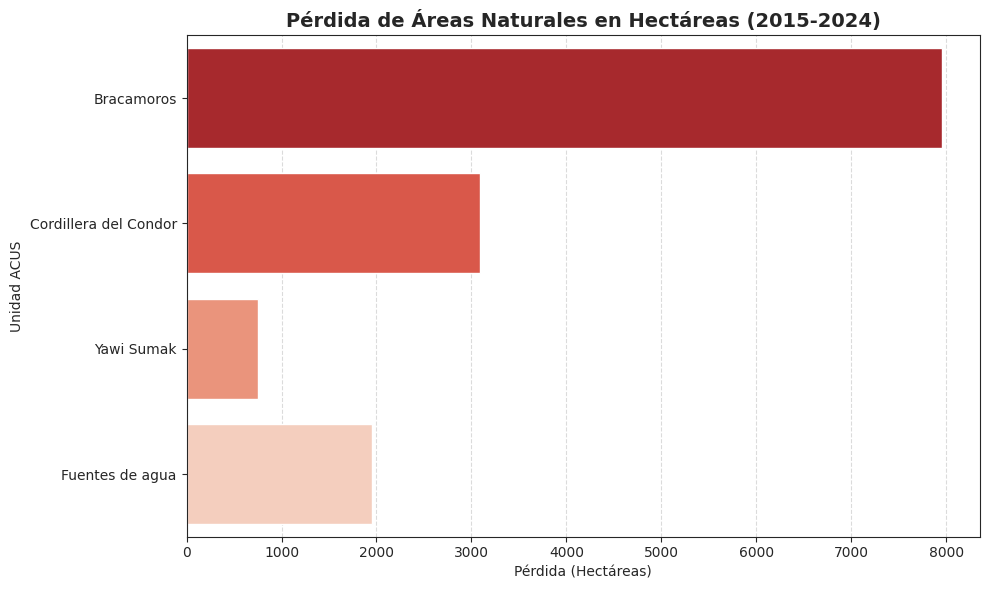

In [38]:
# 1. Definir los IDs de áreas naturales (Forestal + No Forestal)
natural_ids = [1, 3, 4, 5, 6, 10, 11, 12, 13, 29, 81, 82]

# 2. Años de comparación
year_start = 2015
year_end = 2024

print(f"Calculando pérdida de áreas naturales entre {year_start} y {year_end} por unidad ACUS...")

loss_results = []

for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    # Áreas naturales en 2015
    img_2015 = mapbiomas.select(f'classification_{year_start}').clip(unit_geom)
    mask_2015 = img_2015.remap(natural_ids, [1]*len(natural_ids), 0)
    stats_2015 = ee.Image.pixelArea().updateMask(mask_2015).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    # Áreas naturales en 2024
    img_2024 = mapbiomas.select(f'classification_{year_end}').clip(unit_geom)
    mask_2024 = img_2024.remap(natural_ids, [1]*len(natural_ids), 0)
    stats_2024 = ee.Image.pixelArea().updateMask(mask_2024).reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    # Obtener valores y calcular pérdida
    area_2015_ha = (stats_2015.getInfo().get('area') or 0) / 10000
    area_2024_ha = (stats_2024.getInfo().get('area') or 0) / 10000
    loss_ha = area_2015_ha - area_2024_ha

    loss_results.append({
        'Nombre_ACUS': name,
        'Natural_Area_2015_Ha': area_2015_ha,
        'Natural_Area_2024_Ha': area_2024_ha,
        'Pérdida_Ha': loss_ha
    })

df_natural_loss = pd.DataFrame(loss_results)

# 3. Visualizar tabla
display(df_natural_loss.sort_values('Pérdida_Ha', ascending=False))

# 4. Gráfica de pérdida por ACUS
plt.figure(figsize=(10, 6))
sns.barplot(data=df_natural_loss, x='Pérdida_Ha', y='Nombre_ACUS', palette='Reds_r')
plt.title(f'Pérdida de Áreas Naturales en Hectáreas ({year_start}-{year_end})', fontsize=14, fontweight='bold')
plt.xlabel('Pérdida (Hectáreas)')
plt.ylabel('Unidad ACUS')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 4.5. Land use change

### Forest

#### Total

Análisis de transición: ¿A qué cambió el bosque entre 2015 y 2024?


,id,count,Area_Ha,Clase_Destino,Porcentaje_de_la_Pérdida_%
1,21,159057.972549,14315.217529,21. Mosaico de agricultura y/o pastos,86.044460
6,30,11255.423529,1012.988118,30. Minería,6.088766
4,25,11134.674510,1002.120706,25. Otra área antrópica sin vegetación,6.023446
0,13,2129.411765,191.647059,13. Otra formación natural no forestal,1.151933
7,33,1103.509804,99.315882,"33. Río, lago u océano",0.596958
2,23,82.584314,7.432588,"23. Playa, duna o banco de arena",0.044675
9,68,48.988235,4.408941,68. Otra área natural sin vegetación,0.026501
10,81,41.000000,3.690000,81. Herbazales y arbustales andinos,0.022179
3,24,1.000000,0.090000,24. Infraestructura urbana,0.000541
11,9,1.000000,0.090000,9. Silvicultura,0.000541


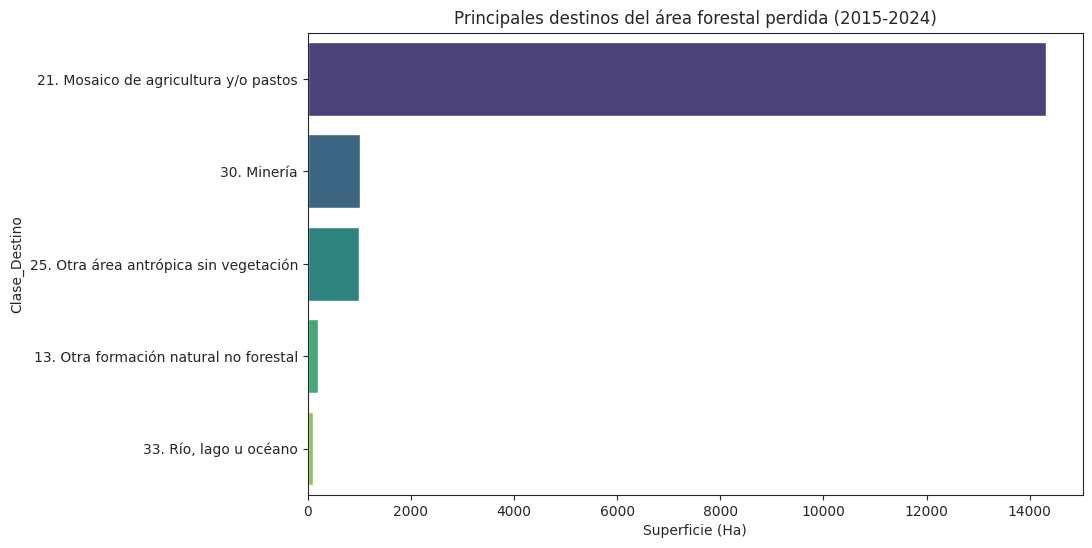

In [41]:
# 1. Definir años y clases de bosque
year_start = 2015
year_end = 2024
forest_classes = [1, 3, 4, 5, 6]

# 2. Cargar imágenes de los dos años
img_start = mapbiomas.select(f'classification_{year_start}').clip(acus)
img_end = mapbiomas.select(f'classification_{year_end}').clip(acus)

# 3. Crear una máscara de las áreas que eran bosque en 2015
forest_mask_2015 = img_start.remap(forest_classes, [1]*len(forest_classes), 0)

# 4. Encontrar áreas donde hubo cambio (era bosque en 2015 pero NO en 2024)
# Multiplicamos la máscara de bosque original por la clasificación final
# para ver a qué clase pertenece ahora ese píxel.
forest_loss_destiny = img_end.updateMask(forest_mask_2015.eq(1))

# 5. Reducción por región para contar los píxeles de destino
stats = forest_loss_destiny.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=acus.geometry(),
    scale=30,
    maxPixels=1e13
)

# 6. Procesar resultados
histogram = stats.getInfo().get(f'classification_{year_end}')

if histogram:
    # Crear DataFrame con las transiciones
    df_trans = pd.DataFrame(list(histogram.items()), columns=['id', 'count'])
    df_trans['id'] = df_trans['id'].astype(float).astype(int)

    # Convertir conteo de píxeles a Hectáreas (30x30m = 900m2 / 10000 = 0.09 ha por píxel)
    df_trans['Area_Ha'] = df_trans['count'] * 0.09

    # Mapear nombres de clases
    id_to_name = {int(k.split('.')[0]): k for k in legend_dict.keys()}
    df_trans['Clase_Destino'] = df_trans['id'].map(id_to_name)

    # Filtrar solo los que NO son bosque en 2024 (para ver la pérdida real)
    # Nota: Si el ID está en forest_classes, significa que se mantuvo como bosque.
    df_loss_only = df_trans[~df_trans['id'].isin(forest_classes)].copy()

    # Calcular porcentaje de la pérdida total
    total_lost = df_loss_only['Area_Ha'].sum()
    df_loss_only['Porcentaje_de_la_Pérdida_%'] = (df_loss_only['Area_Ha'] / total_lost) * 100

    print(f"Análisis de transición: ¿A qué cambió el bosque entre {year_start} y {year_end}?")
    display(df_loss_only.sort_values('Area_Ha', ascending=False))

    # Graficar el principal motor de cambio
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_loss_only.sort_values('Area_Ha', ascending=False).head(5),
                x='Area_Ha', y='Clase_Destino', palette='viridis')
    plt.title(f'Principales destinos del área forestal perdida ({year_start}-{year_end})')
    plt.xlabel('Superficie (Ha)')
    plt.show()
else:
    print("No se detectaron transiciones o datos en el periodo.")

#### ACUS

Analizando transiciones de bosque por ACUS (2015-2024)...

Principales destinos de la pérdida de bosque por unidad:


,Nombre_ACUS,ID_Clase_Destino,Clase_Destino,Area_Ha,Porcentaje_de_la_Pérdida_en_ACUS_%
1,Bracamoros,21,21. Mosaico de agricultura y/o pastos,8484.995294,89.445820
4,Bracamoros,25,25. Otra área antrópica sin vegetación,824.594824,8.692587
5,Bracamoros,30,30. Minería,92.713765,0.977356
0,Bracamoros,13,13. Otra formación natural no forestal,74.143059,0.781590
6,Bracamoros,33,"33. Río, lago u océano",7.397294,0.077980
7,Bracamoros,81,81. Herbazales y arbustales andinos,1.800000,0.018975
2,Bracamoros,23,"23. Playa, duna o banco de arena",0.450000,0.004744
3,Bracamoros,24,24. Infraestructura urbana,0.090000,0.000949
9,Cordillera del Condor,21,21. Mosaico de agricultura y/o pastos,2281.325647,66.948412
12,Cordillera del Condor,30,30. Minería,905.399294,26.570097


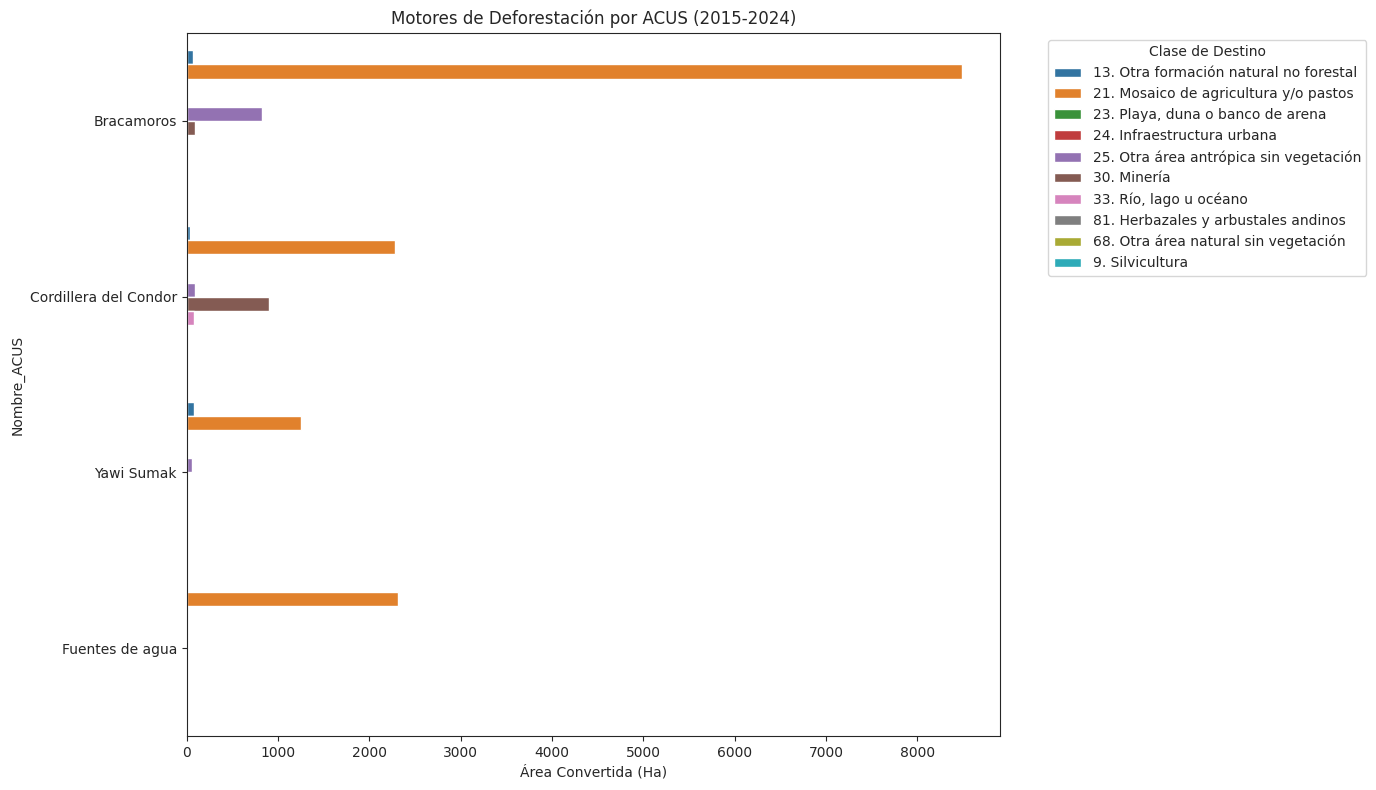

In [42]:
# 1. Definir parámetros
year_start = 2015
year_end = 2024
forest_classes = [1, 3, 4, 5, 6]

acus_transitions = []

print(f"Analizando transiciones de bosque por ACUS ({year_start}-{year_end})...")

# 2. Iterar sobre cada ACUS
for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    # Imágenes de inicio y fin recortadas a la unidad
    img_start = mapbiomas.select(f'classification_{year_start}').clip(unit_geom)
    img_end = mapbiomas.select(f'classification_{year_end}').clip(unit_geom)

    # Máscara de lo que era bosque en el inicio
    forest_mask_start = img_start.remap(forest_classes, [1]*len(forest_classes), 0)

    # Clasificación final solo en los píxeles que eran bosque
    forest_destiny = img_end.updateMask(forest_mask_start.eq(1))

    # Histograma de frecuencias
    stats = forest_destiny.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    hist = stats.getInfo().get(f'classification_{year_end}')

    if hist:
        for class_id, count in hist.items():
            cid = int(float(class_id))
            # Solo nos interesan las áreas que NO son bosque al final (pérdida)
            if cid not in forest_classes:
                area_ha = count * 0.09
                acus_transitions.append({
                    'Nombre_ACUS': name,
                    'ID_Clase_Destino': cid,
                    'Clase_Destino': id_to_name.get(cid, 'Desconocido'),
                    'Area_Ha': area_ha
                })

# 3. Procesar y mostrar resultados
df_unit_trans = pd.DataFrame(acus_transitions)

if not df_unit_trans.empty:
    # Calcular el porcentaje de pérdida relativo a cada ACUS
    df_unit_trans['Porcentaje_de_la_Pérdida_en_ACUS_%'] = df_unit_trans.groupby('Nombre_ACUS')['Area_Ha'].transform(lambda x: (x / x.sum()) * 100)

    print("\nPrincipales destinos de la pérdida de bosque por unidad:")
    display(df_unit_trans.sort_values(['Nombre_ACUS', 'Area_Ha'], ascending=[True, False]))

    # Gráfico comparativo
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_unit_trans, x='Area_Ha', y='Nombre_ACUS', hue='Clase_Destino')
    plt.title(f'Motores de Deforestación por ACUS ({year_start}-{year_end})')
    plt.xlabel('Área Convertida (Ha)')
    plt.legend(title='Clase de Destino', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No se detectaron pérdidas de bosque significativas en las unidades para este periodo.")

### All natural areas

Analizando transiciones de TODAS las áreas naturales por ACUS (2015-2024)...

Principales destinos de la pérdida de áreas naturales (Bosque + No Bosque) por unidad:


,Nombre_ACUS,ID_Clase_Destino,Clase_Destino,Area_Ha,Porcentaje_de_la_Pérdida_Natural_%
0,Bracamoros,21,21. Mosaico de agricultura y/o pastos,8525.162118,90.140785
3,Bracamoros,25,25. Otra área antrópica sin vegetación,831.794824,8.794981
4,Bracamoros,30,30. Minería,92.713765,0.980309
5,Bracamoros,33,"33. Río, lago u océano",7.397294,0.078215
1,Bracamoros,23,"23. Playa, duna o banco de arena",0.450000,0.004758
2,Bracamoros,24,24. Infraestructura urbana,0.090000,0.000952
6,Cordillera del Condor,21,21. Mosaico de agricultura y/o pastos,2281.595647,66.759786
10,Cordillera del Condor,30,30. Minería,905.399294,26.492101
8,Cordillera del Condor,25,25. Otra área antrópica sin vegetación,94.541647,2.766301
11,Cordillera del Condor,33,"33. Río, lago u océano",84.852706,2.482801


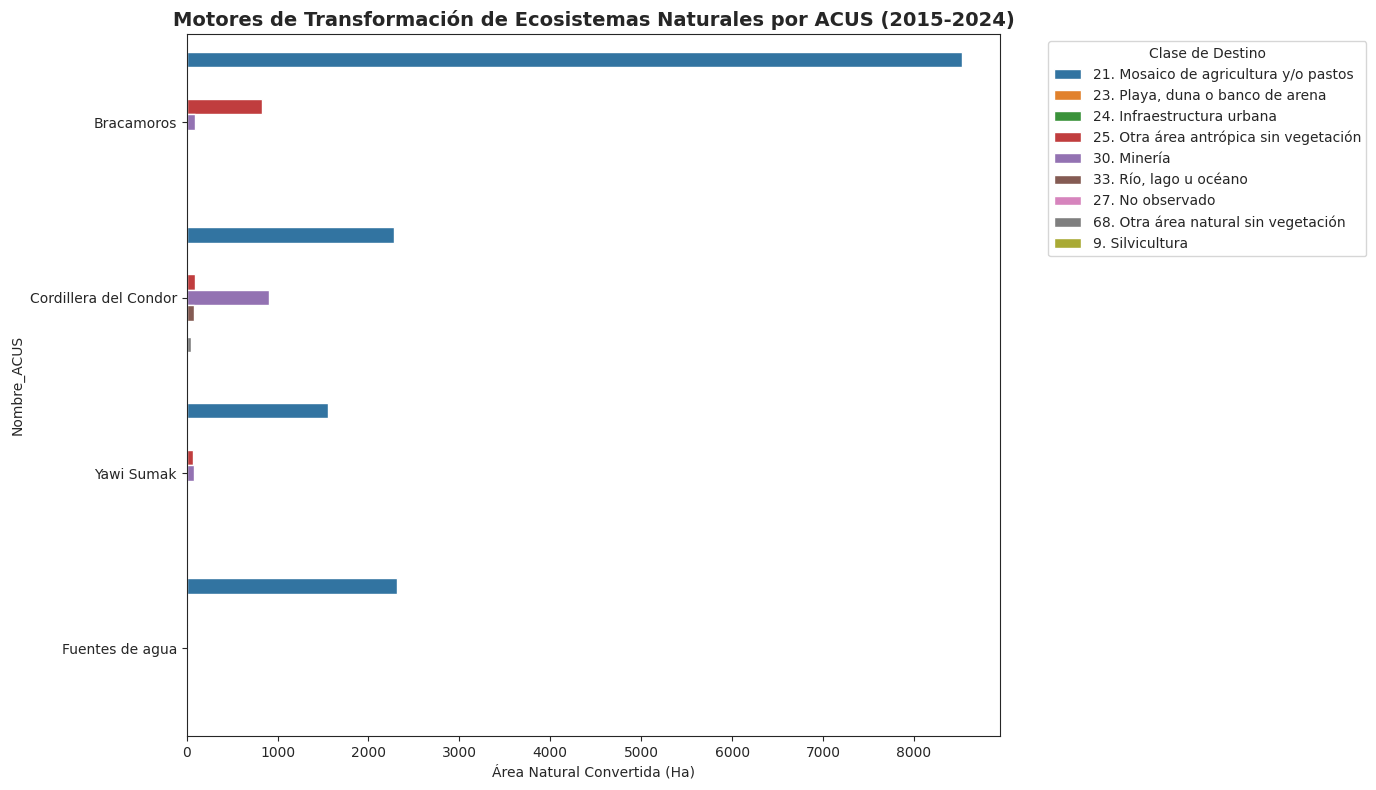

In [43]:
# 1. Definir parámetros y todas las clases naturales
year_start = 2015
year_end = 2024
natural_ids = [1, 3, 4, 5, 6, 10, 11, 12, 13, 29, 81, 82]

acus_natural_transitions = []

print(f"Analizando transiciones de TODAS las áreas naturales por ACUS ({year_start}-{year_end})...")

# 2. Iterar sobre cada ACUS para calcular destinos de la pérdida natural
for name in acus_list:
    unit_geom = acus.filter(ee.Filter.eq('Nombre', name)).geometry()

    img_start = mapbiomas.select(f'classification_{year_start}').clip(unit_geom)
    img_end = mapbiomas.select(f'classification_{year_end}').clip(unit_geom)

    # Máscara de lo que era NATURAL (bosque o no bosque) en el inicio
    natural_mask_start = img_start.remap(natural_ids, [1]*len(natural_ids), 0)

    # Clasificación final solo en los píxeles que eran naturales originalmente
    natural_destiny = img_end.updateMask(natural_mask_start.eq(1))

    # Histograma de frecuencias para ver en qué se convirtieron
    stats = natural_destiny.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=unit_geom,
        scale=30,
        maxPixels=1e13
    )

    hist = stats.getInfo().get(f'classification_{year_end}')

    if hist:
        for class_id, count in hist.items():
            cid = int(float(class_id))
            # Solo nos interesan las áreas que NO son naturales al final (pérdida antropogénica/otros)
            if cid not in natural_ids:
                area_ha = count * 0.09
                acus_natural_transitions.append({
                    'Nombre_ACUS': name,
                    'ID_Clase_Destino': cid,
                    'Clase_Destino': id_to_name.get(cid, f'Clase {cid}'),
                    'Area_Ha': area_ha
                })

# 3. Procesar y mostrar resultados
df_natural_trans = pd.DataFrame(acus_natural_transitions)

if not df_natural_trans.empty:
    # Calcular el porcentaje de pérdida relativo a la pérdida total de cada ACUS
    df_natural_trans['Porcentaje_de_la_Pérdida_Natural_%'] = df_natural_trans.groupby('Nombre_ACUS')['Area_Ha'].transform(lambda x: (x / x.sum()) * 100)

    print("\nPrincipales destinos de la pérdida de áreas naturales (Bosque + No Bosque) por unidad:")
    display(df_natural_trans.sort_values(['Nombre_ACUS', 'Area_Ha'], ascending=[True, False]))

    # Gráfico comparativo
    plt.figure(figsize=(14, 8))
    sns.barplot(data=df_natural_trans, x='Area_Ha', y='Nombre_ACUS', hue='Clase_Destino')
    plt.title(f'Motores de Transformación de Ecosistemas Naturales por ACUS ({year_start}-{year_end})', fontsize=14, fontweight='bold')
    plt.xlabel('Área Natural Convertida (Ha)')
    plt.legend(title='Clase de Destino', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("No se detectó pérdida de áreas naturales en el periodo analizado.")

### Mining areas

¿Qué coberturas se perdieron para dar paso a la Minería? (2015-2024)


,id,Cobertura_Original_2015,Area_Ha,Porcentaje_del_Cambio_%
3,3,3. Bosque,1012.988118,66.048440
0,21,21. Mosaico de agricultura y/o pastos,383.610353,25.012007
6,81,81. Herbazales y arbustales andinos,76.770000,5.005526
4,33,"33. Río, lago u océano",55.848706,3.641425
2,25,25. Otra área antrópica sin vegetación,4.404000,0.287148
1,24,24. Infraestructura urbana,0.082941,0.005408
5,68,68. Otra área natural sin vegetación,0.000706,0.000046


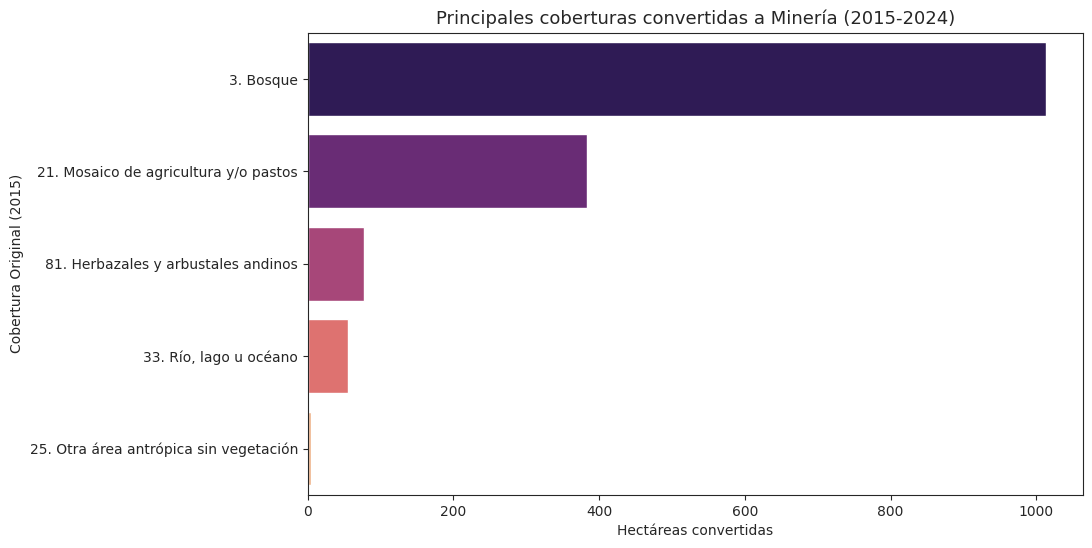

In [44]:
# 1. Definir parámetros
year_start = 2015
year_end = 2024
mining_id = 30

# 2. Cargar imágenes
img_start = mapbiomas.select(f'classification_{year_start}').clip(acus)
img_end = mapbiomas.select(f'classification_{year_end}').clip(acus)

# 3. Identificar áreas que en 2024 son Minería pero en 2015 NO lo eran
# Esto nos da la 'Nueva Minería'
new_mining_mask = img_end.eq(mining_id).And(img_start.neq(mining_id))

# 4. Ver qué cobertura tenían esos píxeles en 2015
mining_origin = img_start.updateMask(new_mining_mask)

# 5. Calcular estadísticas de origen
stats = mining_origin.reduceRegion(
    reducer=ee.Reducer.frequencyHistogram(),
    geometry=acus.geometry(),
    scale=30,
    maxPixels=1e13
)

# 6. Procesar resultados
hist = stats.getInfo().get(f'classification_{year_start}')

if hist:
    df_mining_origin = pd.DataFrame(list(hist.items()), columns=['id', 'count'])
    df_mining_origin['id'] = df_mining_origin['id'].astype(float).astype(int)
    df_mining_origin['Area_Ha'] = df_mining_origin['count'] * 0.09

    # Mapear nombres
    id_to_name = {int(k.split('.')[0]): k for k in legend_dict.keys()}
    df_mining_origin['Cobertura_Original_2015'] = df_mining_origin['id'].map(id_to_name)

    # Calcular porcentaje
    total_converted = df_mining_origin['Area_Ha'].sum()
    df_mining_origin['Porcentaje_del_Cambio_%'] = (df_mining_origin['Area_Ha'] / total_converted) * 100

    print(f"¿Qué coberturas se perdieron para dar paso a la Minería? ({year_start}-{year_end})")
    df_mining_origin = df_mining_origin.sort_values('Area_Ha', ascending=False)
    display(df_mining_origin[['id', 'Cobertura_Original_2015', 'Area_Ha', 'Porcentaje_del_Cambio_%']])

    # Visualización gráfica
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_mining_origin.head(5), x='Area_Ha', y='Cobertura_Original_2015', palette='magma')
    plt.title(f'Principales coberturas convertidas a Minería ({year_start}-{year_end})', fontsize=13)
    plt.xlabel('Hectáreas convertidas')
    plt.ylabel('Cobertura Original (2015)')
    plt.show()
else:
    print("No se detectó expansión minera significativa en el periodo analizado.")

## 4.6. Export